In [1]:
#https://nbviewer.org/github/Neuroinflab/PyMICE/blob/tutorials/tutorial/python3/Tutorial%20on%20advanced%20topics.ipynb
import pymice as pm
import glob

pm.getTutorialData(quiet=True)

dataFiles = glob.glob('C57_AB/*.zip')

In [26]:
ml = pm.Loader('C57_AB/2012-08-28 15.33.58.zip')

#To have the list ordered by one attribute pass the name of the attribute as the order parameter.


visits = ml.getVisits(order='Start')
for visit in visits[:5]:
    print(visit.Start)

2012-08-28 15:34:14.140000+02:00
2012-08-28 15:34:18.625000+02:00
2012-08-28 15:34:27.375000+02:00
2012-08-28 15:34:40.140000+02:00
2012-08-28 15:34:42.171000+02:00


In [43]:
from datetime import datetime, time, timedelta

def get_zeitgeber_time(clock_dt, zt0_time):
    """
    Convert clock time to Zeitgeber Time (ZT), supporting timezone-aware datetimes.

    :param clock_dt: datetime with or without timezone
    :param zt0_time: time object (assumed to be in the same timezone as clock_dt)
    :return: Zeitgeber Time as float (0 <= ZT < 24)
    """
    # Use the timezone from the input datetime, if available
    tzinfo = clock_dt.tzinfo
    zt0_dt = datetime.combine(clock_dt.date(), zt0_time, tzinfo=tzinfo)

    # Adjust ZT0 to the previous day if clock time is earlier
    if clock_dt < zt0_dt:
        zt0_dt -= timedelta(days=1)

    # Time difference in hours
    delta = clock_dt - zt0_dt
    zt_hours = delta.total_seconds() / 3600

    return round(zt_hours % 24, 2)


# ZT0 at 0:00 (local time assumed to match clock_time's timezone)
zt0 = time(0, 0)


visits = ml.getVisits(mice='C57 A 1')
# print(len(visits))
# print(visits[321].Animal)
# print(visits[321].Corner)
# print(visits[321].Cage)
print(visits[321].Start)
zt = get_zeitgeber_time(visits[321].Start, zt0)
print(f"ZT: {zt}")  # Should print something like ZT: 4.08
# print(visits[321].End)

2012-08-30 11:05:00.750000+02:00
ZT: 11.08


In [25]:
visits = ml.getVisits(order='Animal.Name')
for visit in visits[::500]:
    print(visit.Animal.Name)

C57 A 1
C57 A 10
C57 A 11
C57 A 2
C57 A 3
C57 A 4
C57 A 6
C57 A 8
C57 A 9
C57 B 1
C57 B 10
C57 B 12
C57 B 2
C57 B 4
C57 B 5
C57 B 9


In [14]:
#It is possible to have visits ordered firstly by one attibute, then by another one (and so on) by passing a sequence of attribute names as order parameter.



visits = ml.getVisits(order=('Cage', 'Corner'))
for visit in visits[::500]:
    print('Animal %s - cage %d - corner %d / duration %s - %s' % (visit.Animal.Name, visit.Cage, visit.Corner, str(visit.Start), str(visit.End)))

Animal C57 B 11 - cage 1 - corner 1 / duration 2012-08-28 15:38:30.937000+02:00 - 2012-08-28 15:39:21.171000+02:00
Animal C57 B 11 - cage 1 - corner 1 / duration 2012-08-30 22:07:43.562000+02:00 - 2012-08-30 22:07:45.781000+02:00
Animal C57 B 12 - cage 1 - corner 2 / duration 2012-08-29 21:35:48.015000+02:00 - 2012-08-29 21:35:49.437000+02:00
Animal C57 B 1 - cage 1 - corner 3 / duration 2012-08-28 18:44:40.843000+02:00 - 2012-08-28 18:45:02.125000+02:00
Animal C57 B 3 - cage 1 - corner 3 / duration 2012-08-30 08:42:15.609000+02:00 - 2012-08-30 08:42:31.625000+02:00
Animal C57 B 12 - cage 1 - corner 4 / duration 2012-08-28 21:59:14.921000+02:00 - 2012-08-28 21:59:37.421000+02:00
Animal C57 B 6 - cage 1 - corner 4 / duration 2012-08-30 19:57:50.437000+02:00 - 2012-08-30 20:00:06.343000+02:00
Animal C57 A 1 - cage 2 - corner 1 / duration 2012-08-29 15:58:56.281000+02:00 - 2012-08-29 15:59:03.375000+02:00
Animal C57 A 4 - cage 2 - corner 2 / duration 2012-08-28 15:48:59.484000+02:00 - 201

Visits of a particular mouse
It is common to analyse visits of cetrain animal.

To select visits of a particular mouse pass its name as the mice parameter of .getVisits() method.

In [6]:
visits = ml.getVisits(mice='C57 A 1')
print(len(visits))
print(visits[321].Animal)

493
C57 A 1


### Visits of a group of mice
The mice parameter accepts also multiple names.

In [7]:
visits = ml.getVisits(mice=['C57 A 1', 'C57 A 2'])
visitorNames = [v.Animal.Name for v in visits]
for mouse in set(visitorNames):
    print('%s: %d visits' % (mouse, visitorNames.count(mouse)))

C57 A 1: 493 visits
C57 A 2: 281 visits


### Visits performed at particular time
Analyses are very often focused on a certain time period (e.g. phase of experiment phase).

To select visits before or after particular time you can use (respectively) start and end parameters of getVisits() method.

In the example visits started between 15:00 (inclusive) and 16:00 (exclusive) 28th August 2012 are being selected. The time is given as Eastern European Time (EET).

In [8]:
from datetime import datetime
import pytz

EET = pytz.timezone('Etc/GMT-2')

timeFrom = datetime(2012, 8, 28, 15, 0, tzinfo=EET)
timeTo = datetime(2012, 8, 28, 16, 0, tzinfo=EET)

visits = ml.getVisits(start=timeFrom, end=timeTo)
print(min(v.Start for v in visits))
print(max(v.Start for v in visits))

2012-08-28 15:34:14.140000+02:00
2012-08-28 15:59:48.546000+02:00


### Loading a configuration file
To load a configuration file pass a path to it to the class constructor. Then you will be able to list defined time period (with .sections() method) and get their boundaries (with .getTime() method).

In [15]:
timeline = pm.Timeline('C57_AB/timeline.ini')

for timePeriod in timeline.sections():
    start, end = timeline.getTimeBounds(timePeriod)
    print("%s:\t%s - %s" % (timePeriod, start, end))

SA 1 dark:	2012-08-28 13:00:00+02:00 - 2012-08-29 01:00:00+02:00
SA 1 light:	2012-08-29 01:00:00+02:00 - 2012-08-29 13:00:00+02:00
SA 2 dark:	2012-08-29 13:00:00+02:00 - 2012-08-30 01:00:00+02:00
SA 2 light:	2012-08-30 01:00:00+02:00 - 2012-08-30 13:00:00+02:00
SA 3 dark:	2012-08-30 13:00:00+02:00 - 2012-08-31 01:00:00+02:00
SA 3 light:	2012-08-31 01:00:00+02:00 - 2012-08-31 13:00:00+02:00
SA 4 dark:	2012-08-31 13:00:00+02:00 - 2012-09-01 01:00:00+02:00
SA 4 light:	2012-09-01 01:00:00+02:00 - 2012-09-01 13:00:00+02:00
SA 5 dark:	2012-09-01 13:00:00+02:00 - 2012-09-02 01:00:00+02:00
SA 5 light:	2012-09-02 01:00:00+02:00 - 2012-09-02 13:00:00+02:00
NPA 1 dark:	2012-09-02 13:00:00+02:00 - 2012-09-03 01:00:00+02:00
NPA 1 light:	2012-09-03 01:00:00+02:00 - 2012-09-03 13:00:00+02:00
NPA 2 dark:	2012-09-03 13:00:00+02:00 - 2012-09-04 01:00:00+02:00
NPA 2 light:	2012-09-04 01:00:00+02:00 - 2012-09-04 13:00:00+02:00
Place Pref 1 dark:	2012-09-04 13:00:00+02:00 - 2012-09-05 01:00:00+02:00
Place 

### Boundaries of many time periods
To get boundaries of a minimal time period covering several time periods defined in the config file pass a collection of their names as a parameter of .getTime() method.

In [10]:
start, end = timeline.getTimeBounds(['Place Pref 1 dark',
                                     'Place Pref 3 light'])
print('%s - %s' % (start, end))

2012-09-04 13:00:00+02:00 - 2012-09-07 13:00:00+02:00


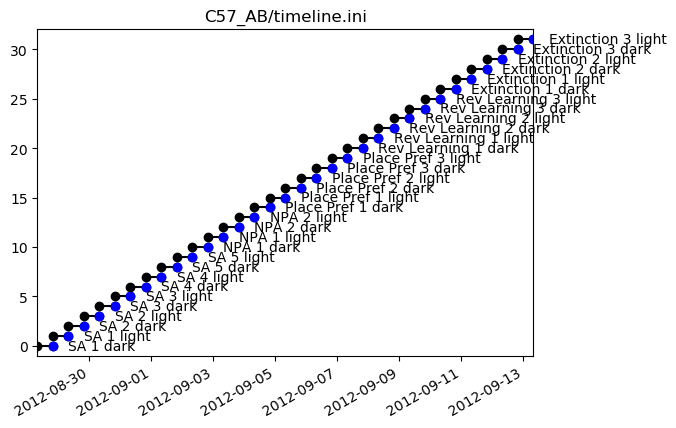

In [11]:
%matplotlib inline

import pymice.debug as pmd
_ = pmd.plotPhases(timeline)

In [17]:
ml = pm.Loader('C57_AB/2012-08-28 15.33.58.zip', getNp=False)
visits = ml.getVisits(order=('Start', 'End'))
visit = visits[4]
print(visit.Nosepokes)

None


In [22]:
print(ml.getLog())
print(ml.getEnvironment())
print(ml.getHardwareEvents())
ml = pm.Loader('C57_AB/2012-08-28 15.33.58.zip', getLog=True, getHw=True, getEnv=True, getNp=True)
print(len(ml.getLog()))
print(len(ml.getEnvironment()))
print(len(ml.getHardwareEvents()))

for v in ml.getVisits(order='Start'):
    print('%s %d %s' % (str(v.Animal), len(v.Nosepokes), list(v.Animal.Tag)[0]))

[< Log Info, Application (at 2012-08-28 15:34:00.093) >, < Log Warning, Lickometer (at 2012-08-28 15:34:54.671) >, < Log Warning, Lickometer (at 2012-08-28 15:34:54.984) >, < Log Warning, Lickometer (at 2012-08-28 15:34:55.953) >, < Log Warning, Lickometer (at 2012-08-28 15:35:03.000) >, < Log Warning, Lickometer (at 2012-08-28 15:36:36.656) >, < Log Warning, Lickometer (at 2012-08-28 15:36:37.296) >, < Log Warning, Lickometer (at 2012-08-28 15:39:56.968) >, < Log Warning, Lickometer (at 2012-08-28 15:42:49.218) >, < Log Warning, Lickometer (at 2012-08-28 15:51:42.890) >, < Log Warning, Lickometer (at 2012-08-28 15:54:16.375) >, < Log Warning, Lickometer (at 2012-08-28 15:54:21.531) >, < Log Warning, Lickometer (at 2012-08-28 15:54:23.000) >, < Log Warning, Lickometer (at 2012-08-28 15:54:41.671) >, < Log Warning, Lickometer (at 2012-08-28 16:03:32.984) >, < Log Warning, Lickometer (at 2012-08-28 16:04:05.156) >, < Log Warning, Lickometer (at 2012-08-28 16:06:01.375) >, < Log Warning, 

In [14]:
loaders = [pm.Loader(filename, getLog=True) for filename in dataFiles]
mm = pm.Merger(*loaders, getLog=True)

dataValidator = pm.DataValidator(pm.LickometerLogAnalyzer(),
                                 pm.PresenceLogAnalyzer())
validatorReport = dataValidator(mm)

/opt/miniconda3/lib/python3.8/site-packages/pymice/LogAnalyser.py:141: MatplotlibDeprecationWarning: Moved to matplotlib.cbook
  idcs = mmlab.contiguous_regions(medHist > self.medThreshold)


In [15]:
start = mm.getStart()
end = mm.getEnd()
interval = (start, end)

strInterval = '(from %s to %s)' % interval

noLickometerProblems = pm.FailureInspector('Lickometer')
noPresenceProblems = pm.FailureInspector('Presence')

if noLickometerProblems(validatorReport, interval):
    print("lickometer ok " + strInterval)

else:
    print("lickometer problem " + strInterval)

if noPresenceProblems(validatorReport, interval):
    print("presences ok " + strInterval)

else:
    print("unknown mice presence problem " + strInterval)

lickometer problem (from 2012-08-28 13:44:52.671000+02:00 to 2012-09-13 13:35:34.390000+02:00)
presences ok (from 2012-08-28 13:44:52.671000+02:00 to 2012-09-13 13:35:34.390000+02:00)


In [ ]:
#https://neuroinflab.github.io/PyMICE/manual.html#module-pymice